In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
import os
import glob
import cv2
import numpy as np
from tqdm import tqdm

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = "/content/drive/MyDrive/kidney_stone_project/data//data/image/1000.tif"
mask_path = "/content/drive/MyDrive/kidney_stone_project/data//data/label/1000.tif"

img = cv2.imread(img_path, 0)
mask = cv2.imread(mask_path, 0)

print(img.shape)
print(mask.shape)

(512, 512)
(512, 512)


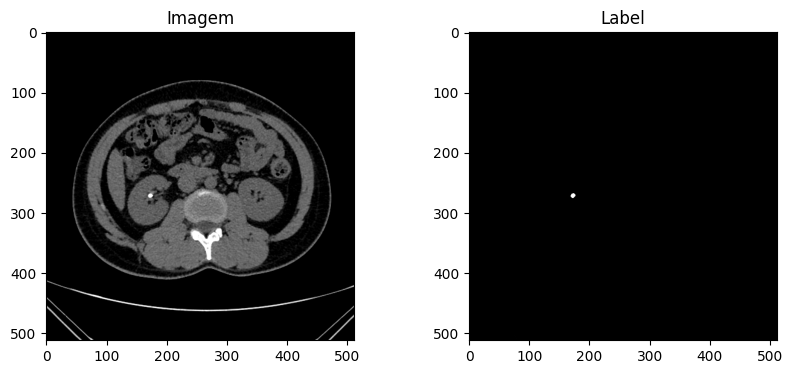

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_path = '/content/drive/MyDrive/kidney_stone_project/data//data/image/1000.tif'
label_path = '/content/drive/MyDrive/kidney_stone_project/data//data/label/1000.tif'

img = cv2.imread(img_path, 0)
label = cv2.imread(label_path, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Imagem")

plt.subplot(1,2,2)
plt.imshow(label, cmap='gray')
plt.title("Label")

plt.show()

In [ ]:
import numpy as np

img = img / 255.0
mask = mask / 255.0

print(img.min(), img.max())
print(mask.min(), mask.max())

0.0 1.0
0.0 1.0


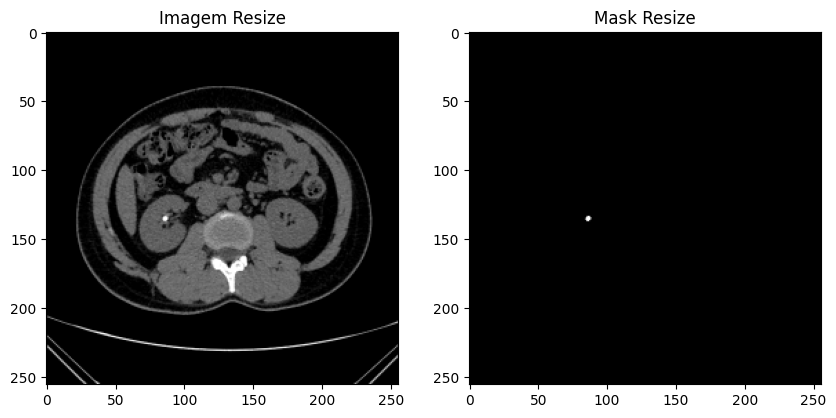

In [ ]:
IMG_SIZE = 256

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_resized, cmap="gray")
plt.title("Imagem Resize")

plt.subplot(1,2,2)
plt.imshow(mask_resized, cmap="gray")
plt.title("Mask Resize")

plt.show()

In [ ]:
img_resized = np.expand_dims(img_resized, axis=-1)
mask_resized = np.expand_dims(mask_resized, axis=-1)

print(img_resized.shape)
print(mask_resized.shape)

(256, 256, 1)
(256, 256, 1)


In [ ]:
image_path = "/content/drive/MyDrive/kidney_stone_project/data//data/image/"
mask_path = "/content/drive/MyDrive/kidney_stone_project/data//data/label/"

In [ ]:
image_files = sorted(glob.glob(image_path + "*.tif"))
mask_files = sorted(glob.glob(mask_path + "*.tif"))

print("Número de imagens:", len(image_files))
print("Número de máscaras:", len(mask_files))

Número de imagens: 838
Número de máscaras: 838


In [ ]:
IMG_SIZE = 256

def load_image(path):
    img = cv2.imread(path, 0)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

In [ ]:
images = []
masks = []

for img_path, mask_path in tqdm(zip(image_files, mask_files),
                                total=len(image_files)):

    img = load_image(img_path)
    mask = load_image(mask_path)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

100%|██████████| 838/838 [00:14<00:00, 57.86it/s]


Images shape: (838, 256, 256, 1)
Masks shape: (838, 256, 256, 1)


In [ ]:
print(images.shape)

(838, 256, 256, 1)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (670, 256, 256, 1)
Teste: (168, 256, 256, 1)


In [ ]:
def unet_model(input_size=(256, 256, 1)):

    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

In [ ]:
model = unet_model()

In [ ]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 256, 256,  │        160 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_36[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ conv2d_37[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_8[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_38[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_40[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 128, 128,  │          0 │ conv2d_41[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 128, 128,  │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 96)               │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 128, 128,  │     27,680 │ concatenate_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 256, 256,  │          0 │ conv2d_42[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 256, 256,  │          0 │ up_sampling2d_9[… │
│ (Concatenate)       │ 48)               │            │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 256, 256,  │      6,928 │ concatenate_9[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 256, 256,  │         17 │ conv2d_43[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 106,417 (415.69 KB)

 Trainable params: 106,417 (415.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import os

image_dir = "/content/drive/MyDrive/kidney_stone_project/data//data/image"
mask_dir = "/content/drive/MyDrive/kidney_stone_project/data//data/label"

images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

print(len(images), len(masks))

838 838


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 256

def load_data(image_list):
    X = []
    Y = []

    for name in image_list:
        img_path = os.path.join(image_dir, name)
        mask_path = os.path.join(mask_dir, name)

        img = cv2.imread(img_path, 0)
        mask = cv2.imread(mask_path, 0)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0
        mask = mask / 255.0

        X.append(img)
        Y.append(mask)

    X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    Y = np.array(Y).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

    return X, Y

In [ ]:
X, Y = load_data(images[:500])

In [ ]:
print(X.shape, Y.shape)

(500, 256, 256, 1) (500, 256, 256, 1)


In [ ]:
history = model.fit(
    X,
    Y,
    epochs=80,
    batch_size=4,
    validation_split=0.2
)

Epoch 1/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9913 - loss: 0.0599 - val_accuracy: 0.9977 - val_loss: 0.0028
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9974 - loss: 0.0048 - val_accuracy: 0.9977 - val_loss: 0.0024
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9974 - loss: 0.0035 - val_accuracy: 0.9977 - val_loss: 0.0017
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9974 - loss: 0.0025 - val_accuracy: 0.9977 - val_loss: 0.0014
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9974 - loss: 0.0023 - val_accuracy: 0.9977 - val_loss: 0.0012
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9974 - loss: 0.0020 - val_accuracy: 0.9977 - val_loss: 0.0012
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9975 - loss: 0.0017 - val_accuracy: 0.9977 - val_loss: 0.0011
Epoch 8/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9976 - loss: 0.0013 - val_accu

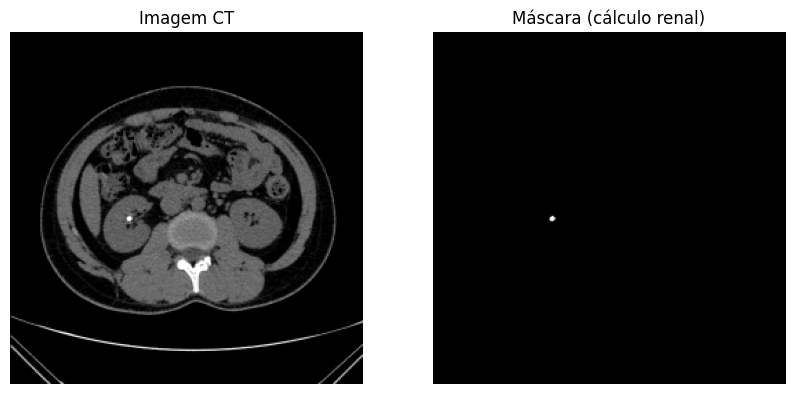

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Imagem CT")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Máscara (cálculo renal)")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
%cd /content/drive/MyDrive/kidney_stone_project/data

/content/drive/MyDrive/kidney_stone_project/data


In [ ]:
!ls -R

.:
data  runs  yolo26n.pt	yolov8n.pt  yolov8s.pt

./data:
image  label

./data/image:
1000.tif  1148.tif  1323.tif  291.tif  390.tif	486.tif  665.tif  838.tif
1001.tif  1149.tif  1324.tif  292.tif  391.tif	487.tif  666.tif  839.tif
1002.tif  1150.tif  1325.tif  293.tif  392.tif	488.tif  667.tif  840.tif
1003.tif  1151.tif  1326.tif  294.tif  393.tif	489.tif  668.tif  841.tif
1012.tif  1152.tif  1327.tif  295.tif  394.tif	48.tif	 669.tif  842.tif
1013.tif  1153.tif  1328.tif  296.tif  395.tif	490.tif  670.tif  843.tif
1014.tif  1154.tif  1329.tif  297.tif  396.tif	491.tif  671.tif  844.tif
1015.tif  1155.tif  1330.tif  298.tif  397.tif	492.tif  672.tif  845.tif
1020.tif  1156.tif  1346.tif  299.tif  398.tif	493.tif  673.tif  846.tif
1021.tif  1157.tif  1347.tif  2.tif    399.tif	497.tif  674.tif  857.tif
1022.tif  1158.tif  1348.tif  300.tif  39.tif	498.tif  675.tif  858.tif
1023.tif  1159.tif  1349.tif  301.tif  3.tif	499.tif  676.tif  859.tif
1024.tif  1160.tif  1350.tif  302.tif  400

In [ ]:
pred = model.predict(X[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


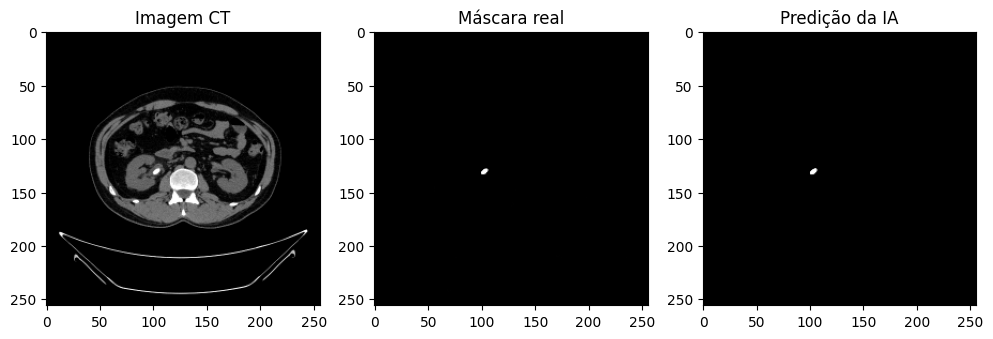

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# imagem original
plt.subplot(1,3,1)
plt.title("Imagem CT")
plt.imshow(X[0].squeeze(), cmap='gray')

# máscara real
plt.subplot(1,3,2)
plt.title("Máscara real")
plt.imshow(Y[0].squeeze(), cmap='gray')

# previsão da IA
plt.subplot(1,3,3)
plt.title("Predição da IA")
plt.imshow(pred[0].squeeze(), cmap='gray')

plt.show()

In [ ]:

import numpy as np

def dice_score(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(np.float32)
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

dice = dice_score(Y[0], pred[0])
print("Dice Score:", dice)

Dice Score: 0.9212891892499544


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


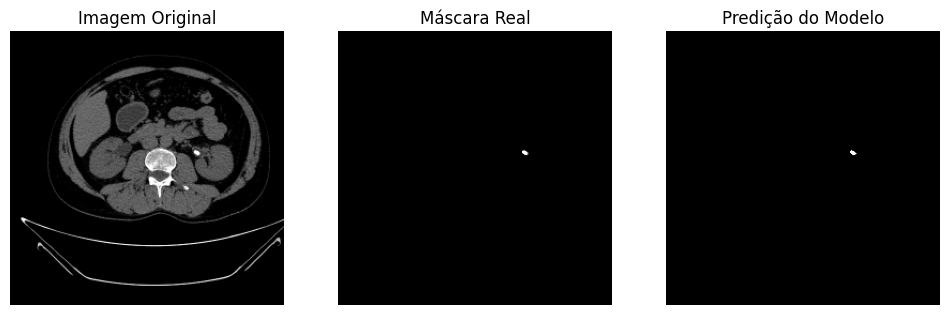

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# escolher uma imagem de teste
idx = 0

img = X_test[idx]
mask_real = y_test[idx]

# previsão
pred = model.predict(np.expand_dims(img, axis=0))[0]

# binarizar previsão
pred_bin = (pred > 0.5).astype(np.float32)

# plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Imagem Original")
plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Máscara Real")
plt.imshow(mask_real.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predição do Modelo")
plt.imshow(pred_bin.squeeze(), cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
# IMPORTS
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

def soft_dice(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

dice = soft_dice(Y[0], pred[0])
print("Soft Dice:", dice)

Soft Dice: 2.940172902338565e-08


In [ ]:
import numpy as np

def dice_score(y_true, y_pred):
    y_pred = (y_pred > 0.05).astype(np.float32)  # ← ajustado
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

dice = dice_score(Y[0], pred[0])
print("Dice Score:", dice)

Dice Score: 0.0


In [ ]:
print("Max predição:", pred[0].max())
print("Min predição:", pred[0].min())

Max predição: 4.723437e-05
Min predição: 8.280412e-09


In [ ]:
import os

print(os.getcwd())  # mostra onde você está
print(os.listdir()) # mostra o que existe na pasta atual

/content/drive/MyDrive/kidney_stone_project/data
['data', 'runs', 'yolov8n.pt', 'yolo26n.pt', 'yolov8s.pt']


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/kidney_stone_project/data//data/image/1000.tif'))

True


In [ ]:

def dice_score(y_true, y_pred):
    smooth = 1e-6
    intersection = np.sum(y_true * y_pred)
    return (2.*intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

scores = []

for i in range(len(X_test)):
    pred = model.predict(np.expand_dims(X_test[i],0))[0]
    pred_bin = (pred > 0.05).astype(np.float32)

    score = dice_score(y_test[i], pred_bin)
    scores.append(score)

print("Dice médio:", np.mean(scores))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

In [ ]:
import cv2

path = '/content/drive/MyDrive/kidney_stone_project/data/data/image/1000.tif'
img = cv2.imread(path, 0)

print(img)
print(type(img))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
<class 'numpy.ndarray'>


In [ ]:
print(type(img))
print(img.dtype)
print(img.shape)

<class 'numpy.ndarray'>
uint8
(512, 512)


uint8
(512, 512)


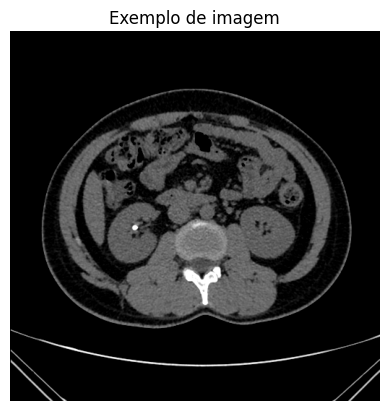

In [ ]:
import cv2
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/kidney_stone_project/data/data/image/1000.tif'

img = cv2.imread(path, 0)

print(img.dtype)
print(img.shape)

plt.imshow(img, cmap='gray')
plt.title("Exemplo de imagem")
plt.axis('off')
plt.show()

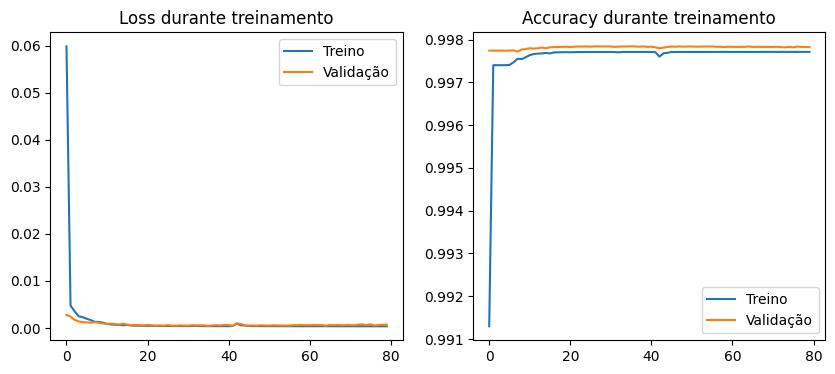

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# LOSS
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title("Loss durante treinamento")
plt.legend()

# ACCURACY
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title("Accuracy durante treinamento")
plt.legend()

plt.show()


In [ ]:
dice_scores = []

for i in range(20):  # testa 20 imagens
    pred = model.predict(X_test[i:i+1])
    pred_bin = (pred > 0.1)

    intersection = np.sum(pred_bin * y_test[i])
    dice = (2 * intersection) / (
        np.sum(pred_bin) + np.sum(y_test[i]) + 1e-8
    )

    dice_scores.append(dice)

print("Dice médio:", np.mean(dice_scores))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Dice médio: 0.7624447922511048


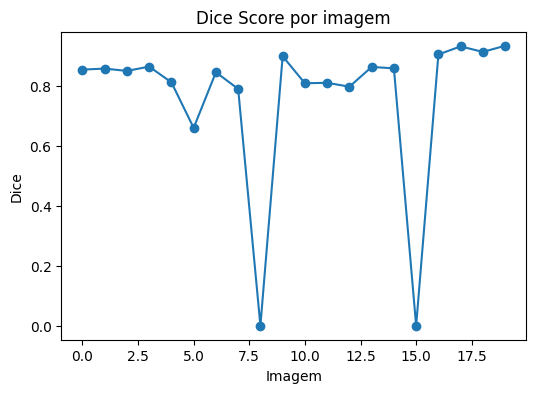

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(dice_scores, marker='o')
plt.title("Dice Score por imagem")
plt.xlabel("Imagem")
plt.ylabel("Dice")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


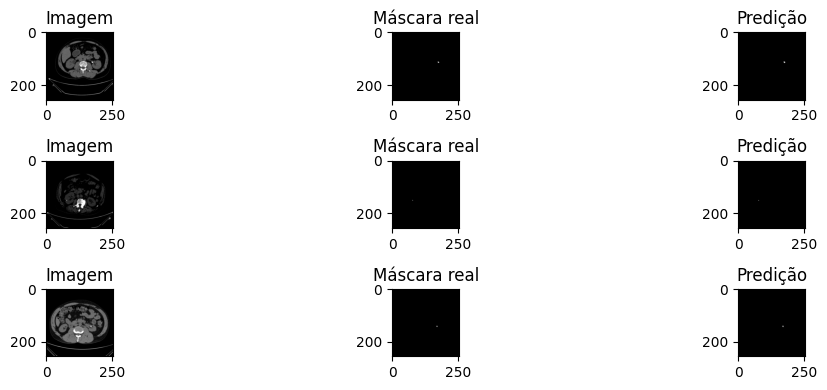

In [ ]:
plt.figure(figsize=(12,4))

for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Imagem")

    plt.subplot(3,3,3*i+2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Máscara real")

    pred = model.predict(X_test[i:i+1])
    plt.subplot(3,3,3*i+3)
    plt.imshow((pred[0]>0.1).squeeze(), cmap='gray')
    plt.title("Predição")

plt.tight_layout()
plt.show()



In [ ]:
import cv2
import numpy as np

def mask_to_bbox(mask):

    mask = (mask > 0.5).astype(np.uint8)

    # encontra componentes conectados
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    if num_labels <= 1:
        return None

    # ignora fundo
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

    x = stats[largest, cv2.CC_STAT_LEFT]
    y = stats[largest, cv2.CC_STAT_TOP]
    w = stats[largest, cv2.CC_STAT_WIDTH]
    h = stats[largest, cv2.CC_STAT_HEIGHT]

    return [x, y, x+w, y+h]

In [ ]:
mask = y_test[0].squeeze()

bbox = mask_to_bbox(mask)

print("Bounding Box:", bbox)


Bounding Box: [np.int32(172), np.int32(111), np.int32(178), np.int32(116)]


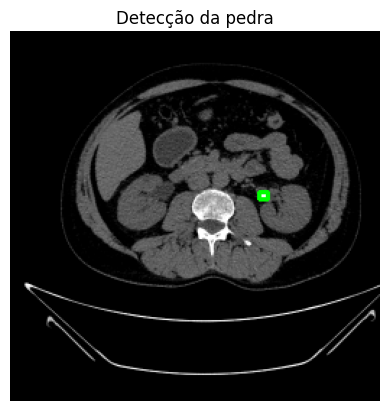

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = X_test[0].squeeze().copy()
img = (img * 255).astype(np.uint8)

bbox = mask_to_bbox(y_test[0].squeeze())

x1, y1, x2, y2 = bbox

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

cv2.rectangle(img_color,
              (x1, y1),
              (x2, y2),
              (0,255,0),
              2)

plt.imshow(img_color)
plt.title("Detecção da pedra")
plt.axis("off")
plt.show()



In [ ]:
bboxes = []

for i in range(len(y_train)):
    bbox = mask_to_bbox(y_train[i].squeeze())
    bboxes.append(bbox)

print("Exemplo:", bboxes[:5])


Exemplo: [[np.int32(99), np.int32(127), np.int32(107), np.int32(134)], [np.int32(160), np.int32(102), np.int32(162), np.int32(104)], [np.int32(177), np.int32(136), np.int32(180), np.int32(138)], [np.int32(163), np.int32(159), np.int32(165), np.int32(161)], [np.int32(171), np.int32(149), np.int32(179), np.int32(155)]]


In [ ]:
!pip install ultralytics





In [ ]:

from ultralytics import YOLO

In [ ]:
import os


base_path = "/content/drive/MyDrive/kidney_stone_project/kidney_yolo"

os.makedirs(base_path + "/images/train", exist_ok=True)
os.makedirs(base_path + "/images/val", exist_ok=True)
os.makedirs(base_path + "/labels/train", exist_ok=True)
os.makedirs(base_path + "/labels/val", exist_ok=True)


In [ ]:
import cv2

def bbox_to_yolo(bbox, img_shape):

    h, w = img_shape

    x_min, y_min, x_max, y_max = bbox

    x_center = ((x_min + x_max) / 2) / w
    y_center = ((y_min + y_max) / 2) / h

    width = (x_max - x_min) / w
    height = (y_max - y_min) / h

    return [0, x_center, y_center, width, height]



In [ ]:
import random

for i in range(len(X_train)):

    img = X_train[i].squeeze()
    mask = y_train[i].squeeze()

    bbox = mask_to_bbox(mask)

    if bbox is None:
        continue

    yolo_box = bbox_to_yolo(bbox, img.shape)

    # decide treino ou validação
    split = "train" if random.random() < 0.8 else "val"

    img_path = f"{base_path}/images/{split}/{i}.png"
    label_path = f"{base_path}/labels/{split}/{i}.txt"

    cv2.imwrite(img_path, (img*255).astype("uint8"))

    with open(label_path, "w") as f:
        f.write(" ".join(map(str, yolo_box)))


In [ ]:
yaml_text = """
path: /content/drive/MyDrive/kidney_stone_project/kidney_yolo
train: images/train
val: images/val

names:
  0: kidney_stone
"""

with open("/content/drive/MyDrive/kidney_stone_project/kidney_yolo/dataset.yaml", "w") as f:
    f.write(yaml_text)


In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/kidney_stone_project/kidney_yolo/dataset.yaml",
    epochs=120,
    imgsz=256
)



Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/kidney_stone_project/kidney_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-9, nbs=64, nms=False, opset=None, optimize=False, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x794b240c4110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model.predict(source="/content/drive/MyDrive/kidney_stone_project/kidney_yolo/images/val", save=True)


TypeError: TensorFlowTrainer.predict() got an unexpected keyword argument 'source'

In [ ]:
results = model.predict(source=img_path, save=True)

In [ ]:
for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()

In [ ]:
# ==========================================
# 1. AVALIAR O MODELO NO CONJUNTO DE TESTE
# ==========================================
# Gera métricas como mAP50, precision e recall

metrics = model.val(
    data="/content/drive/MyDrive/kidney_stone_project/kidney_yolo/dataset.yaml"
)

print("\n===== MÉTRICAS DO MODELO =====")
print("mAP@0.50:", metrics.box.map50)
print("mAP@0.50:0.95:", metrics.box.map)
print("Precisão:", metrics.box.mp)
print("Recall:", metrics.box.mr)




In [ ]:



# ==========================================
# 2. GERAR PREDIÇÃO EM UMA IMAGEM ESPECÍFICA
# ==========================================
# Altere o índice se quiser testar outra imagem

image_path = "/content/drive/MyDrive/kidney_stone_project/kidney_yolo/images/val/31.png"

results = model.predict(
    source=image_path,
    conf=0.25,      # confiança mínima
    save=True,      # salva a imagem com a bounding box
    show=False
)

print("\nImagem com detecção salva em:")
print(results[0].save_dir)



In [ ]:
# ==========================================
# 3. MOSTRAR A IMAGEM GERADA (AJUSTE FINAL)
# ==========================================
# O YOLO salvou as imagens como .jpg, mesmo que a entrada seja .png.

import os
import cv2
import matplotlib.pyplot as plt

# Nome base do arquivo sem extensão
base_name = os.path.splitext(os.path.basename(image_path))[0]

# Caminho correto do arquivo gerado pelo YOLO
output_path = os.path.join(
    str(results[0].save_dir),
    base_name + ".jpg"
)

print("Abrindo:", output_path)

# Carrega a imagem
img_result = cv2.imread(output_path)

if img_result is None:
    print("Erro ao carregar a imagem.")
else:
    # Converter de BGR para RGB
    img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

    # Mostrar imagem
    plt.figure(figsize=(8, 8))
    plt.imshow(img_result)
    plt.title("Detecção com YOLOv8")
    plt.axis("off")
    plt.show()

In [ ]:
boxes = results[0].boxes

if boxes is not None and len(boxes) > 0:
    print("\n===== DETECÇÕES =====")
    for i, box in enumerate(boxes):
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        coords = box.xyxy[0].cpu().numpy()

        print(f"Detecção {i+1}")
        print(f"Classe: {cls} (kidney_stone)")
        print(f"Confiança: {conf:.4f}")
        print(f"Bounding Box [x1, y1, x2, y2]: {coords}")
        print()
else:
    print("\nNenhuma detecção encontrada.")

In [ ]:
# ========= IMPORTS =========

import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import KFold

In [ ]:
# ==========================================
# CONFIGURAÇÕES
# ==========================================

IMG_SIZE = 256
N_SPLITS = 3
EPOCHS = 80
BATCH_SIZE = 4

In [ ]:

# ==========================================
# CAMINHOS
# ==========================================

image_path = "/content/drive/MyDrive/kidney_stone_project/data/data/image/"
mask_path = "/content/drive/MyDrive/kidney_stone_project/data/data/label/"


In [ ]:
# ==========================================
# CARREGAR ARQUIVOS
# ==========================================

image_files = sorted(glob.glob(image_path + "*.tif"))
mask_files = sorted(glob.glob(mask_path + "*.tif"))

print("Número de imagens:", len(image_files))
print("Número de máscaras:", len(mask_files))

In [ ]:
# ==========================================
# FUNÇÃO PARA CARREGAR IMAGEM
# ==========================================

def load_image(path):

    img = cv2.imread(path, 0)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = np.expand_dims(img, axis=-1)

    return img

In [ ]:
# ==========================================
# CARREGAR DATASET
# ==========================================

images = []
masks = []

for img_path, msk_path in tqdm(zip(image_files, mask_files),
                               total=len(image_files)):

    img = load_image(img_path)
    mask = load_image(msk_path)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)


In [ ]:
# ==========================================
# MODELO U-NET
# ==========================================

def unet_model(input_size=(256,256,1)):

    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])

    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])

    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)

    return model

Número de imagens: 838
Número de máscaras: 838


100%|██████████| 838/838 [00:13<00:00, 60.76it/s]


Images shape: (838, 256, 256, 1)
Masks shape: (838, 256, 256, 1)

FOLD 1

Treino: (558, 256, 256, 1)
Teste: (280, 256, 256, 1)
Epoch 1/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9972 - loss: 0.0393 - val_accuracy: 0.9978 - val_loss: 0.0043
Epoch 2/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9977 - loss: 0.0034 - val_accuracy: 0.9978 - val_loss: 0.0026
Epoch 3/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9977 - loss: 0.0021 - val_accuracy: 0.9978 - val_loss: 0.0019
Epoch 4/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9977 - loss: 0.0016 - val_accuracy: 0.9978 - val_loss: 0.0015
Epoch 5/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9978 - loss: 0.0015 - val_accuracy: 0.9978 - val_loss: 0.0020
Epoch 6/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9978 - loss: 0.0012 - val_accuracy: 0.9979 - val_loss: 0.0011
Epoch 7/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9979 - loss: 8.5536e-04 - val_a

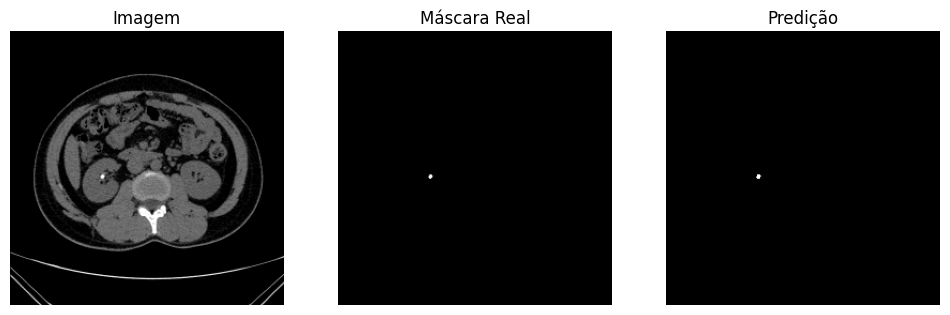

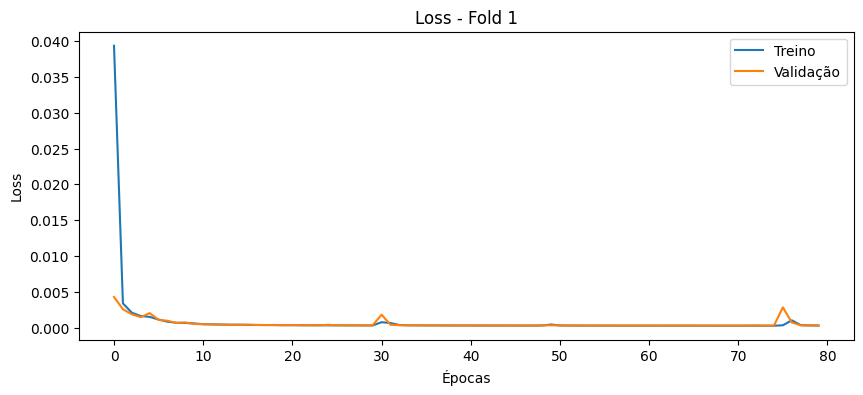


FOLD 2

Treino: (559, 256, 256, 1)
Teste: (279, 256, 256, 1)
Epoch 1/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9978 - loss: 0.0350 - val_accuracy: 0.9977 - val_loss: 0.0046
Epoch 2/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9978 - loss: 0.0032 - val_accuracy: 0.9977 - val_loss: 0.0026
Epoch 3/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9978 - loss: 0.0021 - val_accuracy: 0.9977 - val_loss: 0.0018
Epoch 4/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9978 - loss: 0.0016 - val_accuracy: 0.9978 - val_loss: 0.0013
Epoch 5/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9978 - loss: 0.0012 - val_accuracy: 0.9978 - val_loss: 0.0011
Epoch 6/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9979 - loss: 9.1862e-04 - val_accuracy: 0.9979 - val_loss: 9.7924e-04
Epoch 7/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9979 - loss: 8.2006e-04 - val_accuracy: 0.9979 - val_loss: 6.8782e-04
Epoch 8/80
140/140

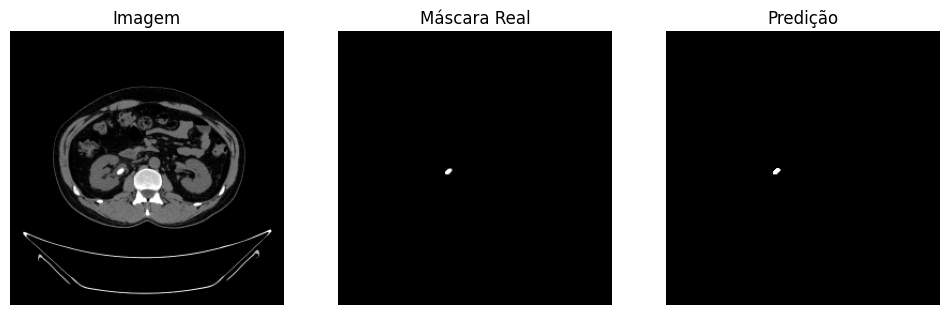

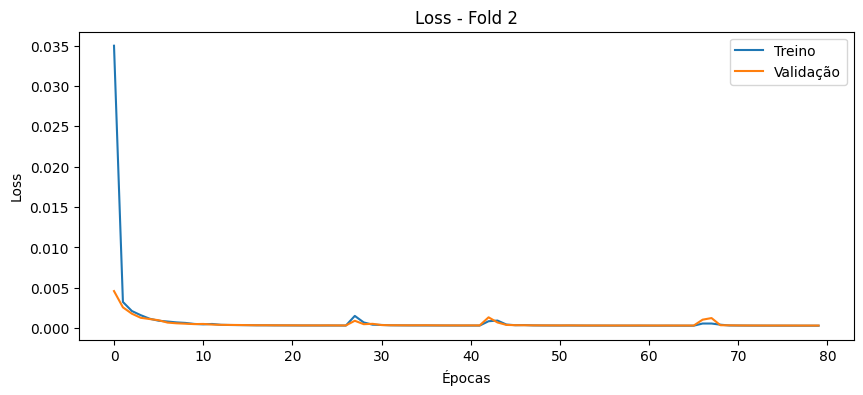


FOLD 3

Treino: (559, 256, 256, 1)
Teste: (279, 256, 256, 1)
Epoch 1/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.9928 - loss: 0.0489 - val_accuracy: 0.9978 - val_loss: 0.0044
Epoch 2/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9977 - loss: 0.0046 - val_accuracy: 0.9978 - val_loss: 0.0041
Epoch 3/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9977 - loss: 0.0037 - val_accuracy: 0.9978 - val_loss: 0.0027
Epoch 4/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9977 - loss: 0.0025 - val_accuracy: 0.9978 - val_loss: 0.0021
Epoch 5/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9977 - loss: 0.0020 - val_accuracy: 0.9978 - val_loss: 0.0015
Epoch 6/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9977 - loss: 0.0016 - val_accuracy: 0.9978 - val_loss: 0.0013
Epoch 7/80
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9977 - loss: 0.0013 - val_accuracy: 0.9978 - val_loss: 0.0011
Epoch 8/80
140/140 ━━━━━━━━━━━━━━━

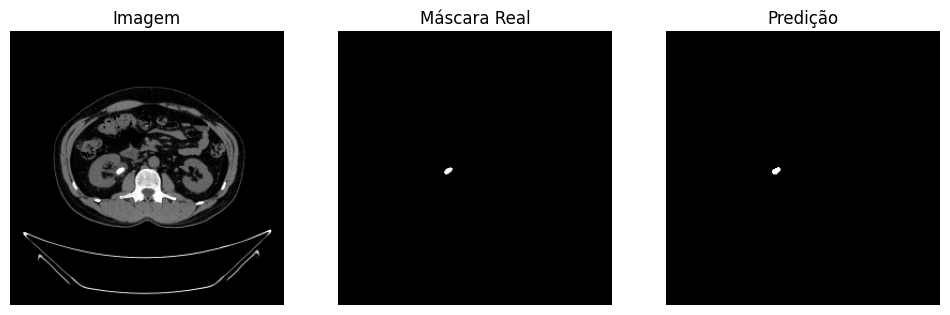

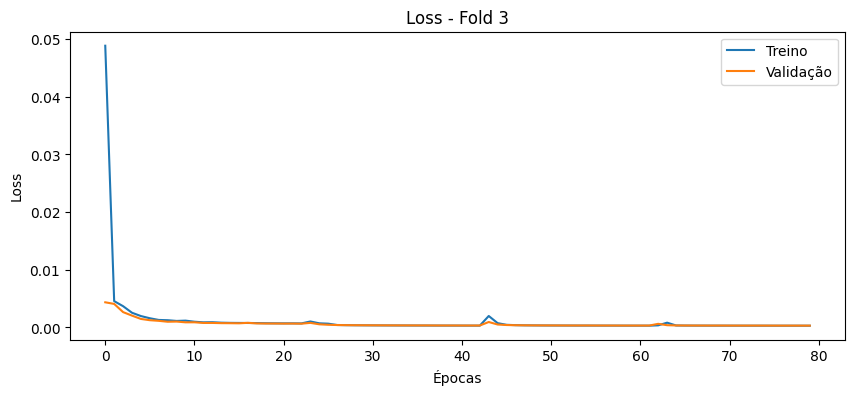


RESULTADO FINAL

Fold 1: 0.7949
Fold 2: 0.8102
Fold 3: 0.8040

Dice médio final: 0.8030366032842154
Desvio padrão: 0.006270119908049878


In [ ]:
# ==========================================
# K-FOLD CROSS VALIDATION (3-FOLD)
# U-NET PARA DETECÇÃO DE CÁLCULO RENAL
# ==========================================

# ========= IMPORTS =========

import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import KFold

# ==========================================
# CONFIGURAÇÕES
# ==========================================

IMG_SIZE = 256
N_SPLITS = 3
EPOCHS = 80
BATCH_SIZE = 4

# ==========================================
# CAMINHOS
# ==========================================

image_path = "/content/drive/MyDrive/kidney_stone_project/data/data/image/"
mask_path = "/content/drive/MyDrive/kidney_stone_project/data/data/label/"

# ==========================================
# CARREGAR ARQUIVOS
# ==========================================

image_files = sorted(glob.glob(image_path + "*.tif"))
mask_files = sorted(glob.glob(mask_path + "*.tif"))

print("Número de imagens:", len(image_files))
print("Número de máscaras:", len(mask_files))

# ==========================================
# FUNÇÃO PARA CARREGAR IMAGEM
# ==========================================

def load_image(path):

    img = cv2.imread(path, 0)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = np.expand_dims(img, axis=-1)

    return img

# ==========================================
# CARREGAR DATASET
# ==========================================

images = []
masks = []

for img_path, msk_path in tqdm(zip(image_files, mask_files),
                               total=len(image_files)):

    img = load_image(img_path)
    mask = load_image(msk_path)

    images.append(img)
    masks.append(mask)

images = np.array(images)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

# ==========================================
# MODELO U-NET
# ==========================================

def unet_model(input_size=(256,256,1)):

    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])

    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])

    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)

    return model

# ==========================================
# DICE SCORE
# ==========================================

def dice_score(y_true, y_pred):

    smooth = 1e-6

    y_pred = (y_pred > 0.1).astype(np.float32)

    intersection = np.sum(y_true * y_pred)

    return (2. * intersection + smooth) / (
        np.sum(y_true) + np.sum(y_pred) + smooth
    )

# ==========================================
# K-FOLD
# ==========================================

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

fold_no = 1

all_scores = []

# ==========================================
# LOOP DOS FOLDS
# ==========================================

for train_index, test_index in kf.split(images):

    print("\n=================================")
    print(f"FOLD {fold_no}")
    print("=================================\n")

    # Divide dados
    X_train = images[train_index]
    X_test = images[test_index]

    y_train = masks[train_index]
    y_test = masks[test_index]

    print("Treino:", X_train.shape)
    print("Teste:", X_test.shape)

    # ==========================================
    # CRIAR MODELO NOVO
    # ==========================================

    model = unet_model()

    # ==========================================
    # COMPILAR
    # ==========================================

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # ==========================================
    # TREINAR
    # ==========================================

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )

    # ==========================================
    # AVALIAÇÃO
    # ==========================================

    scores = []

    for i in range(len(X_test)):

        pred = model.predict(
            np.expand_dims(X_test[i], axis=0),
            verbose=0
        )[0]

        score = dice_score(y_test[i], pred)

        scores.append(score)

    fold_dice = np.mean(scores)

    print(f"\nDice médio Fold {fold_no}: {fold_dice:.4f}")

    all_scores.append(fold_dice)

    # ==========================================
    # MOSTRAR EXEMPLO
    # ==========================================

    idx = 0

    pred = model.predict(
        np.expand_dims(X_test[idx], axis=0),
        verbose=0
    )[0]

    pred_bin = (pred > 0.1).astype(np.float32)

    plt.figure(figsize=(12,4))

    # imagem
    plt.subplot(1,3,1)
    plt.imshow(X_test[idx].squeeze(), cmap='gray')
    plt.title("Imagem")
    plt.axis("off")

    # máscara real
    plt.subplot(1,3,2)
    plt.imshow(y_test[idx].squeeze(), cmap='gray')
    plt.title("Máscara Real")
    plt.axis("off")

    # predição
    plt.subplot(1,3,3)
    plt.imshow(pred_bin.squeeze(), cmap='gray')
    plt.title("Predição")
    plt.axis("off")

    plt.show()

    # ==========================================
    # GRÁFICO LOSS
    # ==========================================

    plt.figure(figsize=(10,4))

    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')

    plt.title(f"Loss - Fold {fold_no}")

    plt.xlabel("Épocas")
    plt.ylabel("Loss")

    plt.legend()

    plt.show()

    fold_no += 1

# ==========================================
# RESULTADO FINAL
# ==========================================

print("\n=================================")
print("RESULTADO FINAL")
print("=================================\n")

for i, score in enumerate(all_scores):
    print(f"Fold {i+1}: {score:.4f}")

print("\nDice médio final:",
      np.mean(all_scores))

print("Desvio padrão:",
      np.std(all_scores))